In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/gapminder.csv')
print(df.head())
print(df.info())

       country  year         pop continent  lifeExp   gdpPercap
0  Afghanistan  1952   8425333.0      Asia   28.801  779.445314
1  Afghanistan  1957   9240934.0      Asia   30.332  820.853030
2  Afghanistan  1962  10267083.0      Asia   31.997  853.100710
3  Afghanistan  1967  11537966.0      Asia   34.020  836.197138
4  Afghanistan  1972  13079460.0      Asia   36.088  739.981106
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   year       1704 non-null   int64  
 2   pop        1704 non-null   float64
 3   continent  1704 non-null   object 
 4   lifeExp    1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 80.0+ KB
None


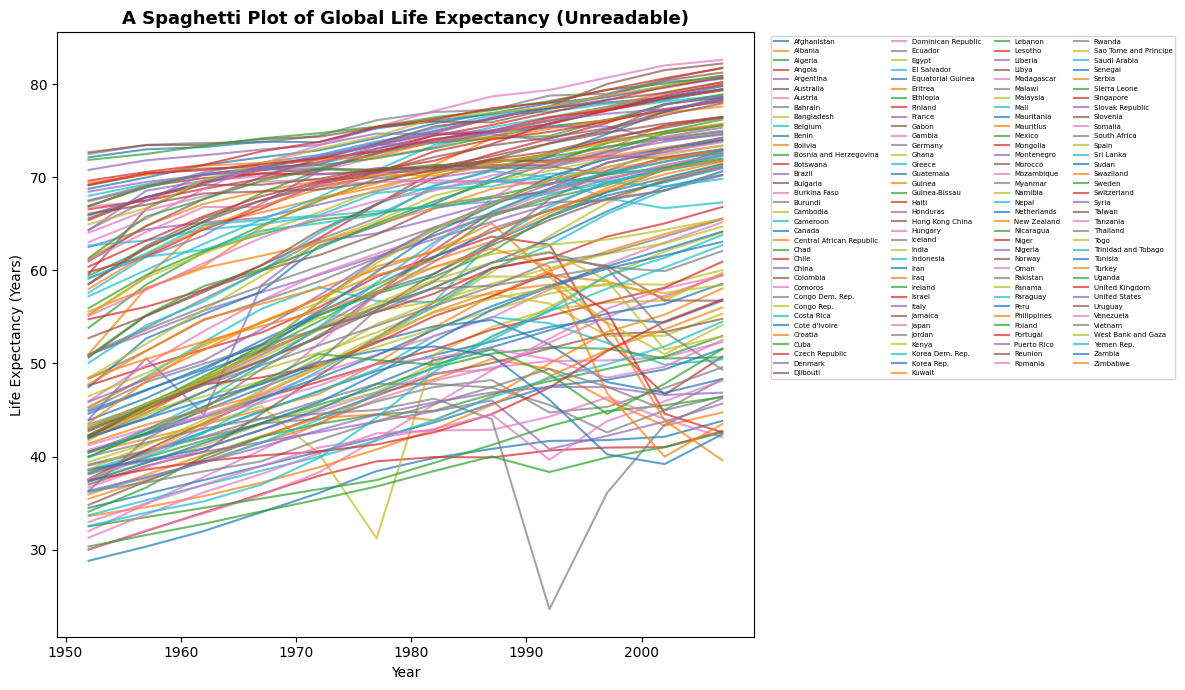

In [2]:
plt.figure(figsize=(12, 7))
for country in df['country'].unique():
    cdata = df[df['country'] == country]
    plt.plot(cdata['year'], cdata['lifeExp'], label=country, alpha=0.7)

plt.title("A Spaghetti Plot of Global Life Expectancy (Unreadable)", fontsize=13, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Life Expectancy (Years)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=4, fontsize=5)
plt.tight_layout()
plt.show()

### What is Wrong with this Chart?
1. **Severe Cognitive Overload:** 142 overlapping colored lines destroy visual hierarchy.
2. **Unusable Legend:** A 142-item legend makes tracking any single country practically impossible.
3. **No Focused Finding:** It dumps raw data without directing the reader's attention to a clear message.

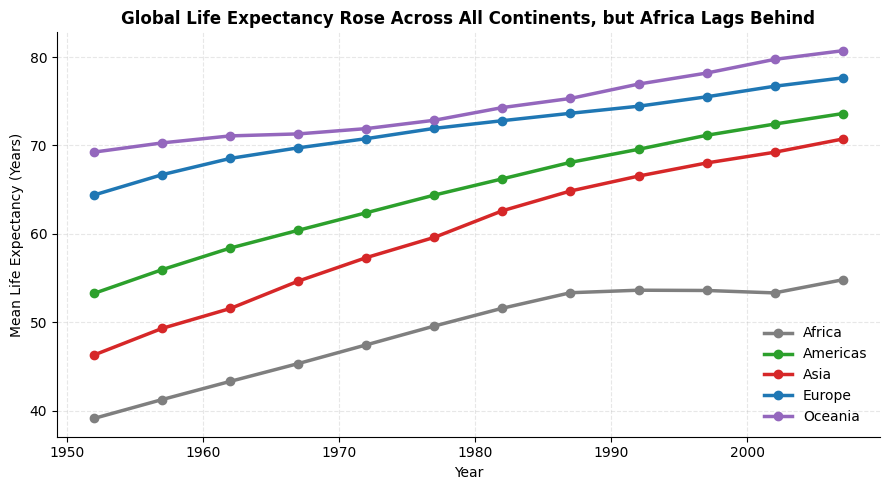

In [3]:
continent_agg = df.groupby(['continent', 'year'])['lifeExp'].mean().reset_index()

plt.figure(figsize=(9, 5))
colors = {'Africa': '#7f7f7f', 'Americas': '#2ca02c', 'Asia': '#d62728', 'Europe': '#1f77b4', 'Oceania': '#9467bd'}
for cont, group in continent_agg.groupby('continent'):
    plt.plot(group['year'], group['lifeExp'], marker='o', lw=2.5, color=colors[cont], label=cont)

plt.title("Global Life Expectancy Rose Across All Continents, but Africa Lags Behind", fontsize=12, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Mean Life Expectancy (Years)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

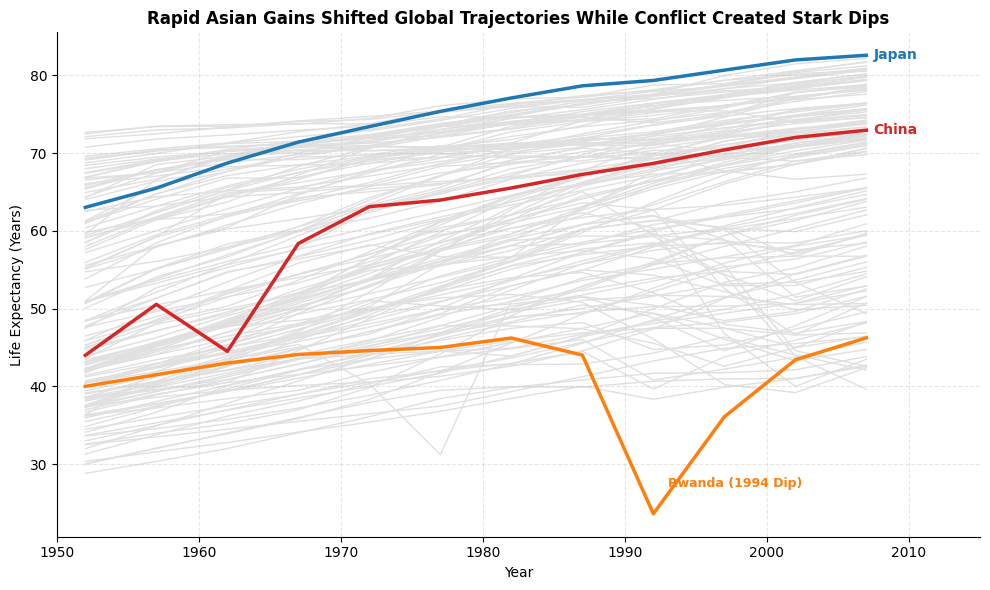

In [4]:
plt.figure(figsize=(10, 6))

for country in df['country'].unique():
    cdata = df[df['country'] == country]
    plt.plot(cdata['year'], cdata['lifeExp'], color='#e0e0e0', lw=1.0, zorder=1)

# Highlight: China (massive gains), Rwanda (1994 genocide dip), Japan (steady leader)
highlights = {
    'Japan': ('#1f77b4', (2007, 82.6)),
    'China': ('#d62728', (2007, 72.96)),
    'Rwanda': ('#ff7f0e', (1992, 23.6))
}

for country, (col, pos) in highlights.items():
    cdata = df[df['country'] == country]
    plt.plot(cdata['year'], cdata['lifeExp'], color=col, lw=2.5, zorder=3)
    last_row = cdata.iloc[-1]
    if country == 'Rwanda':
        plt.text(1993, 27, "Rwanda (1994 Dip)", color=col, fontweight='bold', fontsize=9)
    else:
        plt.text(last_row['year'] + 0.5, last_row['lifeExp'], country, color=col, fontweight='bold', va='center', fontsize=10)

plt.title("Rapid Asian Gains Shifted Global Trajectories While Conflict Created Stark Dips", fontsize=12, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Life Expectancy (Years)")
plt.xlim(1950, 2015)
plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Comparison: Aggregation (a) vs. Highlighting (b)
- **Aggregation (a)** shows broad, macro-level trends cleanly across regions, but it completely erases within-continent variance, outliers, and acute historical shocks (such as Rwanda's 1994 genocide).
- **Highlighting (b)** preserves the overall distribution of all 142 nations in the background while spotlighting specific narratives directly on the plot without needing a legend.

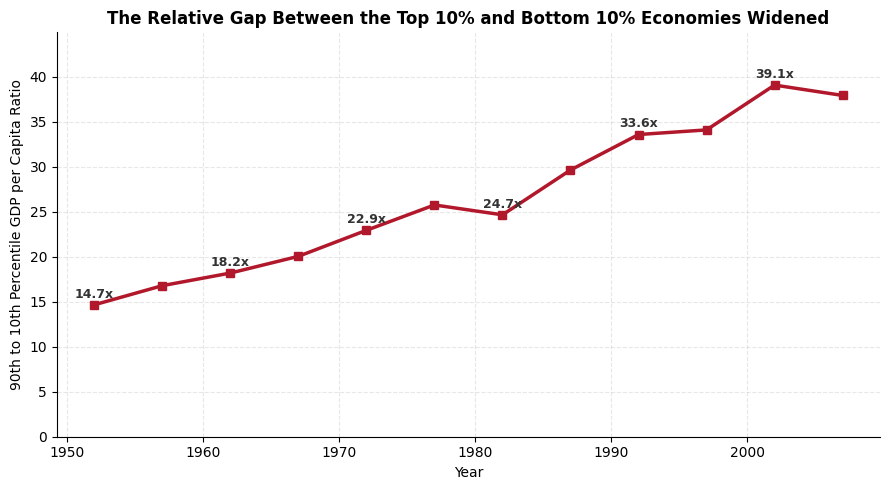

In [5]:
# Measure the 90th-to-10th percentile ratio of GDP per capita over time
p90 = df.groupby('year')['gdpPercap'].quantile(0.90)
p10 = df.groupby('year')['gdpPercap'].quantile(0.10)
ratio = p90 / p10
years = ratio.index

plt.figure(figsize=(9, 5))
plt.plot(years, ratio, marker='s', color='#b2182b', lw=2.5)
plt.title("The Relative Gap Between the Top 10% and Bottom 10% Economies Widened", fontsize=12, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("90th to 10th Percentile GDP per Capita Ratio")
plt.ylim(bottom=0, top=ratio.max() * 1.15)
plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().spines[['top', 'right']].set_visible(False)

for x, y in zip(years[::2], ratio[::2]):
    plt.text(x, y + 0.8, f"{y:.1f}x", ha='center', fontsize=9, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

### Chart Type Justification
We chose a **line chart tracking the 90th-to-10th percentile ratio** over time.
- Tracking raw absolute dollar differences distorts the comparison through global inflation and exponential growth.
- A percentile ratio ($P_{90} / P_{10}$) directly measures relative inequality.
- Starting the y-axis at zero shows honestly that the relative income gap grew from ~14× in 1952 to over 24× by 2007.